In [2]:
import numpy as np
from pyfield.utilities.matlab import mat_struct_to_dict, explore_mat


%load_ext autoreload
%autoreload 2

Settings:

# 1. Import .mat and .npz


In [3]:
def MSE(a, b):
    return np.square(np.subtract(a, b)).mean()

In [4]:
def get_comparison_data(mat_dict, npz_dict):
    
    # Extract pressure fields
    pr_fieldii = mat_dict['pr']
    pr_naive = npz_dict["pr_naive"]/npz_dict["pr_naive"].max()
    pr_sdi = npz_dict["pr_sdi"]/npz_dict["pr_sdi"].max()
    pr_auto = npz_dict["pr_auto"]/npz_dict["pr_auto"].max()
    # Extract times
    t_fieldii = mat_dict['mean_time']
    t_naive = npz_dict['time_naive'] 
    t_sdi = npz_dict['time_sdi']
    t_auto = npz_dict['time_auto']
    std_fieldii = mat_dict['std_time']
    std_naive = npz_dict['std_naive']
    std_sdi = npz_dict['std_sdi']
    std_auto = npz_dict['std_auto']

    # ---------- Compute MSE ---------
    mse_naive = MSE(pr_naive, pr_fieldii)
    mse_sdi = MSE(pr_sdi, pr_fieldii)
    mse_auto = MSE(pr_auto, pr_fieldii)

    return mse_naive, mse_sdi, mse_auto, t_fieldii, t_naive, t_sdi, t_auto, std_fieldii, std_naive, std_sdi, std_auto

In [5]:
import pandas as pd
from IPython.display import display, HTML

def make_table(table_values, table_titles, table_subtitles):
    # Build MultiIndex columns matching your layout
    col_tuples = []
    col_tuples.extend([(table_titles[0], s) for s in table_subtitles[0:5]])        # '', M,P,T,delta k, 8+2 T/M
    col_tuples.append((table_titles[1], table_subtitles[5]))                       # FIELDII -> t_FieldII
    col_tuples.extend([(table_titles[2], s) for s in table_subtitles[6:8]])       # PyField Naive -> t, MSE
    col_tuples.extend([(table_titles[3], s) for s in table_subtitles[8:10]])      # PyField SDI -> t, MSE
    col_tuples.extend([(table_titles[4], s) for s in table_subtitles[10:12]])     # PyField Auto -> t, MSE
    col_tuples.extend([(table_titles[5], s) for s in table_subtitles[12:15]])      # xSpeedup -> Naive, SDI, Auto

    columns = pd.MultiIndex.from_tuples(col_tuples)
    df = pd.DataFrame(table_values, columns=columns)

    # Show in notebook (markdown + HTML)
    # print(df.to_markdown(index=False))
    # display(HTML(df.to_html(index=False)))
    return df

## 1.1. Linear array

In [6]:
from pathlib import Path
from scipy import io as sio

# ---------- find .mat file(s) ---------
BASELINEAR = Path(r"c:\Users\INSERM\Documents\Esteban\PyField\comparison_FIELDII\data\Linear")
BASEMATRIX = Path(r"c:\Users\INSERM\Documents\Esteban\PyField\comparison_FIELDII\data\Matrix")
mats_linear = list(BASELINEAR.glob("*.mat"))
mats_matrix = list(BASEMATRIX.glob("*.mat"))

for i, mat_path in enumerate(mats_linear):
    print(f"idx {i}: {mat_path.name}")

for i, mat_path in enumerate(mats_matrix):
    print(f"idx {i}: {mat_path.name}")

# Order of mats:
#      [       P        ,    T   ,  M  ]
order_idx_linear =[3, 1, 2, 8, 6, 7, 0, 1, 4, 1, 5]
order_idx_matrix =[2, 0, 1, 0, 3, 4, 0, 5, 6]

idx 0: Linear_nsubx1_nsuby10_fs100_nxyz41_P68921_M1280_T725.mat
idx 1: Linear_nsubx1_nsuby10_fs200_nxyz41_P68921_M1280_T1444.mat
idx 2: Linear_nsubx1_nsuby10_fs200_nxyz81_P531441_M1280_T1444.mat
idx 3: Linear_nsubx1_nsuby10_fs200_nxyz9_P729_M1280_T1443.mat
idx 4: Linear_nsubx1_nsuby10_fs300_nxyz41_P68921_M1280_T2164.mat
idx 5: Linear_nsubx2_nsuby20_fs200_nxyz41_P68921_M5120_T1444.mat
idx 6: Linear_nsubx2_nsuby20_fs300_nxyz41_P68921_M5120_T2164.mat
idx 7: Linear_nsubx2_nsuby20_fs300_nxyz81_P531441_M5120_T2164.mat
idx 8: Linear_nsubx2_nsuby20_fs300_nxyz9_P729_M5120_T2162.mat
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
idx 1: Matrix_nsubx1_nsuby1_fs100_nxyz81_P531441_M3025_T767.mat
idx 2: Matrix_nsubx1_nsuby1_fs100_nxyz9_P729_M3025_T767.mat
idx 3: Matrix_nsubx1_nsuby1_fs200_nxyz41_P68921_M3025_T1525.mat
idx 4: Matrix_nsubx1_nsuby1_fs300_nxyz41_P68921_M3025_T2287.mat
idx 5: Matrix_nsubx2_nsuby2_fs100_nxyz41_P68921_M12100_T767.mat
idx 6: Matrix_nsubx3_nsuby3_fs100_nxyz41_

In [7]:
# ---------- prepare table -------
table_titles =    [    ''                                 ,'FIELDII', 'PyField Naive'  ,  'PyField SDI'    ,  'PyField Auto'  ,      "xSpeedup"       ]
table_subtitles = ["P", "T", "M", r"$\Delta k$", "8+2 T/M","t (s)", "t (s)", "MSE (%)", "t (s)", "MSE (%)", "t (s)", "MSE (%)", "Naive", "SDI", "Auto"]
table_values_linear = np.empty((len(order_idx_linear), len(table_subtitles)), dtype=object)

counter = 0
for i in order_idx_linear:
    mat_path = mats_linear[i]
    print(f"idx {i}: {mat_path.name}")

    #  ---------- load pyfield data ---------
    npz_path = mat_path.parent / (mat_path.stem + "_pyfield.npz")
    npz_dict = np.load(str(npz_path), allow_pickle=True)

    #  ---------- load fieldII data ---------
    mat_struct = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)['data']

    # If you want a Python-native copy:
    mat_dict = mat_struct_to_dict(mat_struct)

    #  ---------- get comparison data ---------
    (mse_naive, mse_sdi, mse_auto,
     t_fieldii, t_naive, t_sdi, t_auto,
     std_fieldii, std_naive, std_sdi, std_auto) = get_comparison_data(mat_dict, npz_dict)

    #  ---------- fill table values ---------
    table_line = [npz_dict['P'],
                  npz_dict['T'],
                  npz_dict['M'],
                  f"{npz_dict['deltak']:.2f}",
                  f"{8 + 2 * npz_dict['T']/npz_dict['M']:.2f}",
                  f"{t_fieldii:.3f} ± {std_fieldii:.3f}",
                  f"{t_naive:.3f} ± {std_naive:.3f}",
                  f"{mse_naive*100:.4f}",
                  f"{t_sdi:.3f} ± {std_sdi:.3f}",
                  f"{mse_sdi*100:.4f}",
                  f"{t_auto:.3f} ± {std_auto:.3f}",
                  f"{mse_auto*100:.4f}",
                  f"{t_fieldii/t_naive:.2f}",
                  f"{t_fieldii/t_sdi:.2f}",
                  f"{t_fieldii/t_auto:.2f}",
                  ]
    table_values_linear[counter, :] = table_line

    # print(npz_dict['h_calc_time'])
    print(npz_dict['h_calc_time'])
    counter += 1


idx 3: Linear_nsubx1_nsuby10_fs200_nxyz9_P729_M1280_T1443.mat
[0.00697827 0.01597524 0.01031899 0.01054788 0.01928687 0.00963783
 0.01811099 0.01738548 0.00570273 0.00470781 0.01920295 0.01835537
 0.01812744 0.00544524 0.0159688  0.01569247 0.01311088 0.01597095
 0.00853205 0.00628567 0.01579976]
idx 1: Linear_nsubx1_nsuby10_fs200_nxyz41_P68921_M1280_T1444.mat
[0.45924854 0.47460771 0.45542002 0.47244549 0.50593686 0.49056721
 0.49757957 0.33400273 0.35753107 0.34932184 0.37422729 0.36382318
 0.36319518 0.34736156 0.41046834 0.38481665 0.42130685 0.38035965
 0.4273901  0.41335034 0.42803741]
idx 2: Linear_nsubx1_nsuby10_fs200_nxyz81_P531441_M1280_T1444.mat
[3.48514652 3.88835788 3.80427861 3.78632712 3.76315928 3.76316142
 3.63055158 2.75493383 2.75547171 2.70706797 2.58181334 2.70227027
 2.72016883 2.64493012 3.05019283 3.12147737 3.06845903 2.98445058
 3.07194114 2.976789   2.99595237]
idx 8: Linear_nsubx2_nsuby20_fs300_nxyz9_P729_M5120_T2162.mat
[0.02013731 0.0243876  0.02349114 0.0

In [8]:
make_table(table_values_linear, table_titles, table_subtitles)

FIELDII   PyField Naive  \
         P     T     M $\Delta k$ 8+2 T/M            t (s)           t (s)   
0      729  2066  1280      12.81   11.23    0.089 ± 0.001   0.013 ± 0.003   
1    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
2   531441  2067  1280      12.60   11.23   64.106 ± 1.174   3.749 ± 0.061   
3      729  3078  5120      11.36    9.20    0.200 ± 0.001   0.021 ± 0.001   
4    68921  3079  5120      11.25    9.20   18.559 ± 0.478   1.545 ± 0.025   
5   531441  3079  5120      11.24    9.20  142.778 ± 1.762  11.660 ± 0.052   
6    68921  1034  1280      10.26    9.62    6.932 ± 0.017   0.355 ± 0.005   
7    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
8    68921  3100  1280      15.93   12.84    9.341 ± 0.024   0.633 ± 0.017   
9    68921  2067  1280      12.62   11.23    8.378 ± 0.061   0.479 ± 0.014   
10   68921  2053  5120      10.26    8.80   16.809 ± 0.083   1.342 ± 0.006   

              PyField SDI           PyField Auto         xSpeedup         \
   MSE (%)          t (s) MSE (%)          t (s) MSE (%)    Naive    SDI   
0   0.0026  0.013 ± 0.006  0.0026  0.014 ± 0.003  0.0026     6.89   6.85   
1   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
2   0.0027  2.706 ± 0.036  0.0027  3.034 ± 0.037  0.0027    17.10  23.69   
3   0.0021  0.024 ± 0.002  0.0021  0.017 ± 0.002  0.0021     9.47   8.22   
4   0.0033  1.155 ± 0.010  0.0033  1.174 ± 0.011  0.0033    12.01  16.07   
5   0.0023  8.588 ± 0.038  0.0023  8.665 ± 0.067  0.0023    12.25  16.62   
6   0.0112  0.297 ± 0.006  0.0112  0.300 ± 0.005  0.0112    19.52  23.36   
7   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
8   0.0033  0.394 ± 0.011  0.0033  0.450 ± 0.021  0.0033    14.76  23.69   
9   0.0037  0.356 ± 0.007  0.0037  0.411 ± 0.015  0.0037    17.49  23.52   
10  0.0035  1.092 ± 0.021  0.0035  1.100 ± 0.001  0.0035    12.52  15.39   

           
     Auto  
0    6.44  
1   20.36  
2   21.13  
3   11.52  
4   15.81  
5   16.48  
6   23.14  
7   20.36  
8   20.75  
9   20.36  
10  15.28

## 1.2. Matrix array

In [9]:
table_values_matrix = np.empty((len(order_idx_matrix), len(table_subtitles)), dtype=object)

counter = 0
for i in order_idx_matrix:
    mat_path = mats_matrix[i]
    print(f"idx {i}: {mat_path.name}")

    #  ---------- load pyfield data ---------
    npz_path = mat_path.parent / (mat_path.stem + "_pyfield.npz")
    npz_dict = np.load(str(npz_path), allow_pickle=True)

    #  ---------- load fieldII data ---------
    mat_struct = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)['data']

    # If you want a Python-native copy:
    mat_dict = mat_struct_to_dict(mat_struct)

    #  ---------- get comparison data ---------
    (mse_naive, mse_sdi, mse_auto,
     t_fieldii, t_naive, t_sdi, t_auto,
     std_fieldii, std_naive, std_sdi, std_auto) = get_comparison_data(mat_dict, npz_dict)
    
    print(f"w_c = 8 c/ fs : {8*npz_dict['c']/npz_dict['sampling_frequency']*1000:.2f} mm, and w_x, w_x = {npz_dict['tx_element_width_mm']:.2f}, {npz_dict['tx_element_height_mm']:.2f} mm")

    #  ---------- fill table values ---------
    table_line = [npz_dict['P'],
                  npz_dict['T'],
                  npz_dict['M'],
                  f"{npz_dict['deltak']:.2f}",
                  f"{8 + 2 * npz_dict['T']/npz_dict['M']:.2f}",
                  f"{t_fieldii:.3f} ± {std_fieldii:.3f}",
                  f"{t_naive:.3f} ± {std_naive:.3f}",
                  f"{mse_naive*100:.4f}",
                  f"{t_sdi:.3f} ± {std_sdi:.3f}",
                  f"{mse_sdi*100:.4f}",
                  f"{t_auto:.3f} ± {std_auto:.3f}",
                  f"{mse_auto*100:.4f}",
                  f"{t_fieldii/t_naive:.2f}",
                  f"{t_fieldii/t_sdi:.2f}",
                  f"{t_fieldii/t_auto:.2f}",
                  ]
    table_values_matrix[counter, :] = table_line

    # print(npz_dict['h_calc_time'])
    print("speedup PyField vs FieldII (naive, sdi, auto): {:.2f}x, {:.2f}x, {:.2f}x".format(
        t_fieldii / t_naive,
        t_fieldii / t_sdi,
        t_fieldii / t_auto
    ))
    counter += 1

idx 2: Matrix_nsubx1_nsuby1_fs100_nxyz9_P729_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 50.68x, 59.51x, 79.39x
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 70.51x, 135.07x, 133.52x
idx 1: Matrix_nsubx1_nsuby1_fs100_nxyz81_P531441_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 68.19x, 132.12x, 131.08x
idx 0: Matrix_nsubx1_nsuby1_fs100_nxyz41_P68921_M3025_T767.mat
w_c = 8 c/ fs : 0.12 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 70.51x, 135.07x, 133.52x
idx 3: Matrix_nsubx1_nsuby1_fs200_nxyz41_P68921_M3025_T1525.mat
w_c = 8 c/ fs : 0.06 mm, and w_x, w_x = 0.29, 0.29 mm
speedup PyField vs FieldII (naive, sdi, auto): 49.39x, 134.57x, 130.02x
idx 4: Matrix_nsubx1_nsuby1_fs300_nxyz41_P68921_M3025_T228

In [10]:
make_table(table_values_matrix, table_titles, table_subtitles)

FIELDII  PyField Naive  \
        P     T      M $\Delta k$ 8+2 T/M            t (s)          t (s)   
0     729  1485   3025      18.06    8.98    0.899 ± 0.004  0.018 ± 0.003   
1   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
2  531441  1485   3025      17.95    8.98  648.655 ± 2.396  9.512 ± 0.069   
3   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
4   68921  2970   3025      32.45    9.96   96.962 ± 0.990  1.963 ± 0.021   
5   68921  4455   3025      47.27   10.95  108.164 ± 1.944  2.701 ± 0.036   
6   68921  1485   3025      17.96    8.98   88.855 ± 1.957  1.260 ± 0.015   
7   68921  1471  12100      11.53    8.24  110.910 ± 0.434  3.365 ± 0.024   
8   68921  1467  27225      10.21    8.11  149.683 ± 1.184  6.748 ± 0.010   

             PyField SDI           PyField Auto         xSpeedup          \
  MSE (%)          t (s) MSE (%)          t (s) MSE (%)    Naive     SDI   
0  0.0077  0.015 ± 0.004  0.0077  0.011 ± 0.002  0.0077    50.68   59.51   
1  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
2  0.0035  4.910 ± 0.041  0.0035  4.948 ± 0.033  0.0035    68.19  132.12   
3  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
4  0.0009  0.721 ± 0.026  0.0009  0.746 ± 0.030  0.0009    49.39  134.57   
5  0.0008  0.795 ± 0.034  0.0008  0.825 ± 0.044  0.0008    40.04  136.01   
6  0.0035  0.658 ± 0.018  0.0035  0.665 ± 0.019  0.0035    70.51  135.07   
7  0.0021  2.365 ± 0.015  0.0021  2.420 ± 0.023  0.0021    32.96   46.90   
8  0.0011  5.281 ± 0.031  0.0011  5.488 ± 0.037  0.0011    22.18   28.35   

           
     Auto  
0   79.39  
1  133.52  
2  131.08  
3  133.52  
4  130.02  
5  131.11  
6  133.52  
7   45.84  
8   27.27

# 2. Pressure Field Visualization

In [11]:
import matplotlib.pyplot as plt
import pyvista as pv
import numpy as np

import pyfield
import pyfield.transducers as transducers
from pyfield.psimulation import PyField

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2.1. Import .mat data

In [12]:
# Import mat
from pathlib import Path
from scipy import io as sio
from pyfield.utilities.matlab import mat_struct_to_dict, explore_mat

# ---------- find .mat file(s) ---------
BASE = Path(r"c:\Users\INSERM\Documents\Esteban\PyField\comparison_FIELDII\data")

filename_matrix = 'Matrix_nsubx2_nsuby2_fs200_nxyz51_P132651_M12100_T358_focal.mat'
filename_linear = 'Linear_nsubx1_nsuby10_fs200_nxyz101_P1030301_M1280_T315_nocurv.mat'

file_path_matrix = BASE / filename_matrix
file_path_linear = BASE / filename_linear

#  ---------- load fieldII data ---------
mat_struct = sio.loadmat(file_path_matrix, squeeze_me=True, struct_as_record=False)['data']

# If you want a Python-native copy:
mat_matrix = mat_struct_to_dict(mat_struct)

#  ---------- load fieldII data ---------
mat_struct = sio.loadmat(file_path_linear, squeeze_me=True, struct_as_record=False)['data']

# If you want a Python-native copy:
mat_linear = mat_struct_to_dict(mat_struct)

## 2.2. Simulation with pyfield

### 2.2.1. Define Field

In [13]:
# ------- focus and simulation window (input parameters) -------
x_extent_mm = [-0.5, 0.5]
y_extent_mm = [-0.5, 0.5]
z_extent_mm = [7, 9]
focus_mm = [0.0, 0.0, 8]

dx_mm = 0.02
dy_mm = dx_mm*np.diff(y_extent_mm)/np.diff(x_extent_mm)
dz_mm = dx_mm*np.diff(z_extent_mm)/np.diff(x_extent_mm)

field_info_matrix_mm = {
        "x_extent": x_extent_mm,
        "y_extent": y_extent_mm,
        "z_extent": z_extent_mm,
        "dx": dx_mm,
        "dy": dy_mm,
        "dz": dz_mm,
    }

dx_mm = 0.01
dy_mm = dx_mm*np.diff(y_extent_mm)/np.diff(x_extent_mm)
dz_mm = dx_mm*np.diff(z_extent_mm)/np.diff(x_extent_mm)

field_info_linear_mm = {
        "x_extent": x_extent_mm,
        "y_extent": y_extent_mm,
        "z_extent": z_extent_mm,
        "dx": dx_mm,
        "dy": dy_mm,
        "dz": dz_mm,
    }


### 2.2.2. Define Transducers

#### Linear


LinearArrayTransducer initialized in 0.0089 seconds.


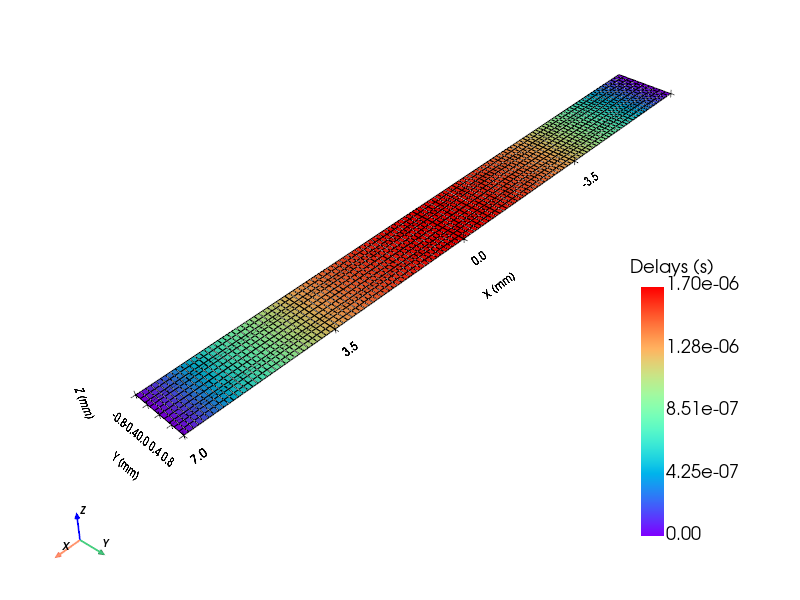

In [14]:
# ------------------ Saving / options -----------------------
frequency_MHz = 12.5
c = 1540.0  # m/s

#  ------------------- transducer characteristics --------------------
tx_N_elements = 128
tx_element_height_mm = 1.5
tx_width_mm = 0.108
tx_pitch_mm = 0.11
tx_kerf_mm = tx_pitch_mm - tx_width_mm
tx_elevationFocus_mm = 1000
tx_frequency_Hz = frequency_MHz * 1e6
no_sub_x = 1
no_sub_y = 10

# Create transducer     
Linear_transducer = transducers.LinearArrayTransducer(
        n_elements=tx_N_elements,
        element_width_mm=tx_width_mm,
        element_height_mm=tx_element_height_mm,
        elevation_focus_mm=tx_elevationFocus_mm,
        kerf_mm=tx_kerf_mm,
        no_sub_x=no_sub_x,
        no_sub_y=no_sub_y,
        frequency_Hz=tx_frequency_Hz,
    )

Linear_transducer.compute_delays(focus_mm=focus_mm)
Linear_transducer.show(scalars='Delays', notebook = True, jupyter_backend='static')

#### Matrix

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.

Transducer initialized in 0.0622 seconds.


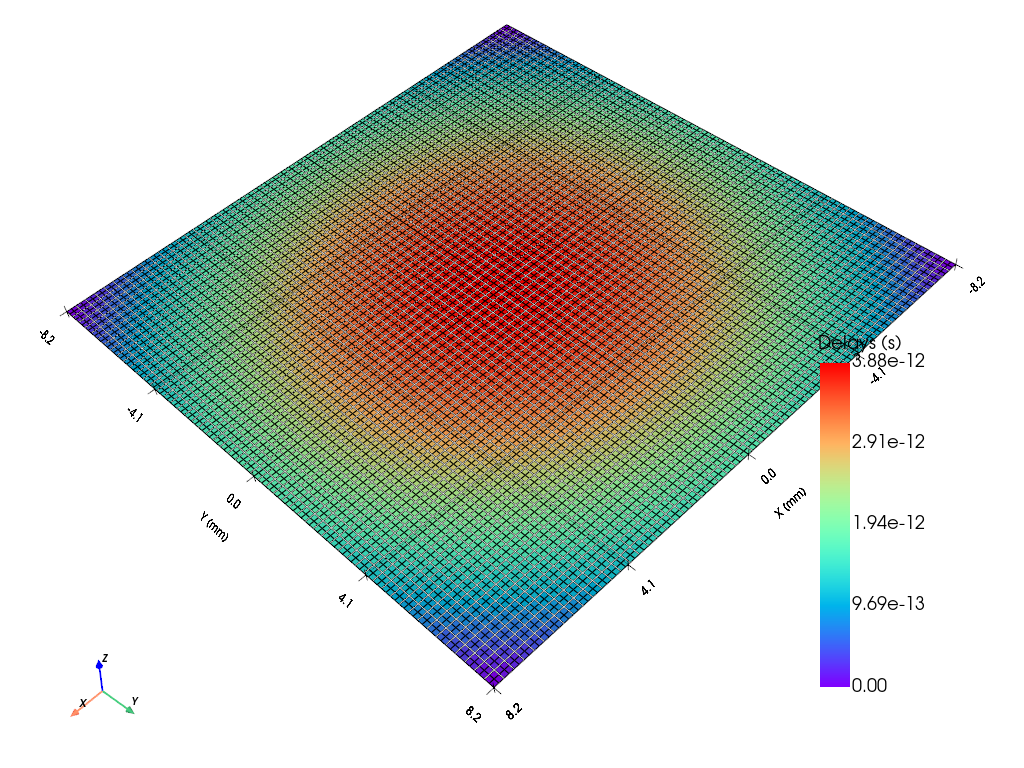

In [15]:
# ------------------ Saving / options -----------------------
frequency_MHz = 10
c = 1540.0  # m/s

#  ------------------- transducer characteristics --------------------
tx_N_elem_x = 55
tx_N_elem_y = 55
tx_elem_width_mm = 0.29
tx_elem_height_mm = 0.29
tx_pitch_mm = 0.3
tx_kerf_x_mm = tx_pitch_mm - tx_elem_width_mm
tx_kerf_y_mm = tx_pitch_mm - tx_elem_height_mm
tx_frequency_Hz = frequency_MHz * 1e6  # MHz
no_sub_x = 2
no_sub_y = 2

# Create transducer     
Matrix_transducer = transducers.MatrixArrayTransducer(
        N_elem_x=tx_N_elem_x,
        N_elem_y=tx_N_elem_y,
        elem_width_mm=tx_elem_width_mm,
        elem_height_mm=tx_elem_height_mm,
        kerf_x_mm=tx_kerf_x_mm,
        kerf_y_mm=tx_kerf_y_mm,
        no_sub_x=no_sub_x,
        no_sub_y=no_sub_x,
        frequency_Hz=tx_frequency_Hz,  # MHz),
    )

Matrix_transducer.compute_delays(focus_mm=focus_mm)
Matrix_transducer.show(scalars='Delays', notebook = True, jupyter_backend='static')

### 2.2.3. Perform simulations

In [16]:
# from pyfield.psimulation import TorchField

Matrix_field = PyField(Matrix_transducer)
x_m,y_m,z_m, pr_pyfield_matrix = Matrix_field(field_info_matrix_mm, method = 'auto', normalize=True)

Min distance must be >> w^2/(4*lambda): 0.0341 mm

Computing SIR for 132651 points and 12100 patches with method auto...
Min distance: 7.00 mm, Max distance: 15.21 mm
Computed time grid from 4.45 us to 13.85 us, with 1880 samples in 1.96 seconds.
Transducer SIR computed in 10.909 seconds...
Pressure computed from SIR in 1.06 seconds...
Pressure field computed in 12.64 seconds... 



In [21]:
x_m,y_m,z_m, pr_pyfield_matrix = Matrix_field(field_info_matrix_mm, method = 'auto', normalize=True)


Computing SIR for 132651 points and 12100 patches with method auto...
Min distance: 7.00 mm, Max distance: 15.21 mm
Computed time grid from 4.45 us to 13.85 us, with 1880 samples in 0.40 seconds.
Transducer SIR computed in 4.804 seconds...
Pressure computed from SIR in 0.99 seconds...
Pressure field computed in 6.54 seconds... 



In [17]:
Linear_field = PyField(Linear_transducer)
x_l,y_l,z_l, pr_pyfield_linear = Linear_field(field_info_linear_mm, method = 'auto', normalize=True)

Min distance must be >> w^2/(4*lambda): 0.0457 mm

Computing SIR for 1030301 points and 1280 patches with method auto...
Min distance: 7.00 mm, Max distance: 11.76 mm
Computed time grid from 4.46 us to 9.42 us, with 993 samples in 0.33 seconds.
Transducer SIR computed in 4.867 seconds...
Pressure computed from SIR in 5.26 seconds...
Pressure field computed in 10.76 seconds... 



In [22]:
x_l,y_l,z_l, pr_pyfield_linear = Linear_field(field_info_linear_mm, method = 'auto', normalize=True)


Computing SIR for 1030301 points and 1280 patches with method auto...
Min distance: 7.00 mm, Max distance: 11.76 mm
Computed time grid from 4.46 us to 9.42 us, with 993 samples in 0.31 seconds.
Transducer SIR computed in 4.563 seconds...
Pressure computed from SIR in 5.08 seconds...
Pressure field computed in 10.34 seconds... 



## 2.3. Comparison between FIELDII and PyField

In [23]:
pr_fieldii_matrix = mat_matrix['pr']/np.max(mat_matrix['pr'])
pr_fieldii_linear = mat_linear['pr']/np.max(mat_linear['pr'])

In [24]:
print("Matlab time for matrix field : ", mat_matrix['h_calc_time'])
print("Matlab time for Linear field : ", mat_linear['h_calc_time'])

Matlab time for matrix field :  259.2589856
Matlab time for Linear field :  102.4020472


### 2.3.1. 2D Planes

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 51/101, 51/101, 51/101


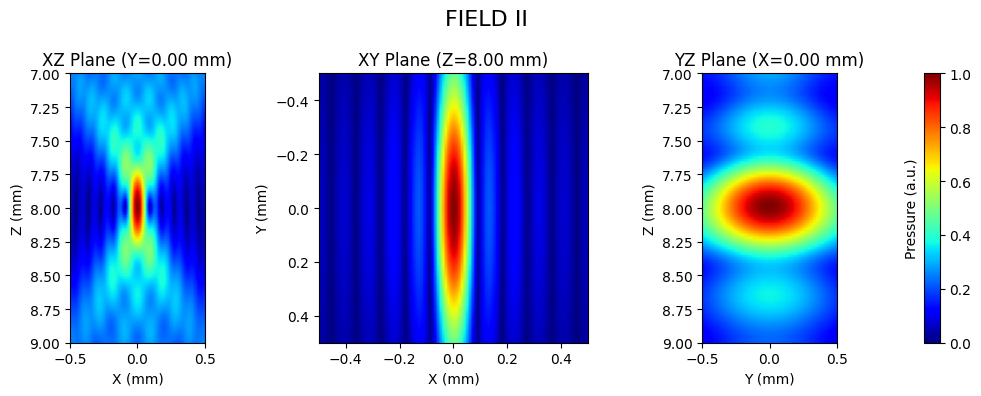

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 51/101, 51/101, 51/101


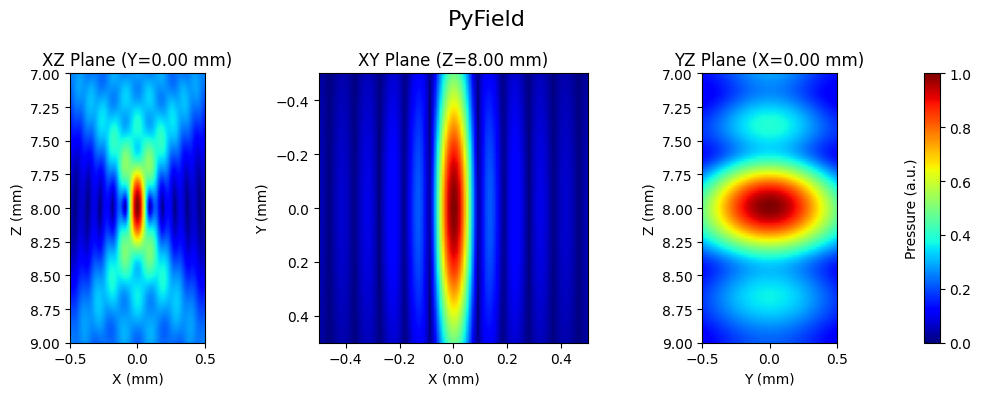

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 51/101, 51/101, 51/101


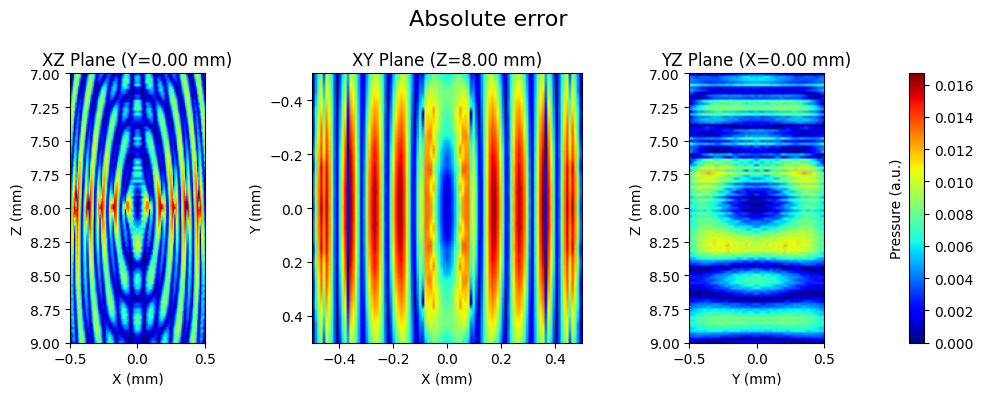

In [48]:
pyfield.plot_field_planes(x_l,y_l,z_l, pr_fieldii_linear, vmin = 0, vmax = 1, figsize = (10,4), title="FIELD II")
pyfield.plot_field_planes(x_l,y_l,z_l, pr_pyfield_linear, vmin = 0, vmax = 1, figsize = (10,4), title="PyField")
pyfield.plot_field_planes(x_l,y_l,z_l, np.abs(pr_pyfield_linear-pr_fieldii_linear), figsize = (10,4), title="Absolute error")

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


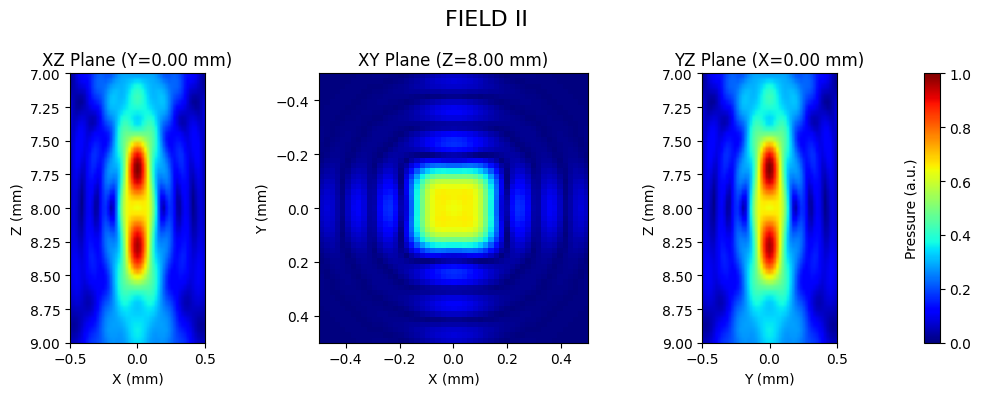

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


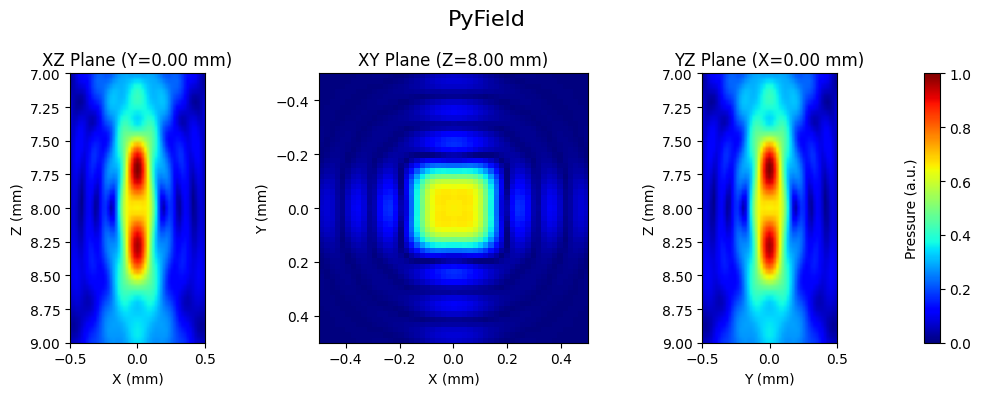

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


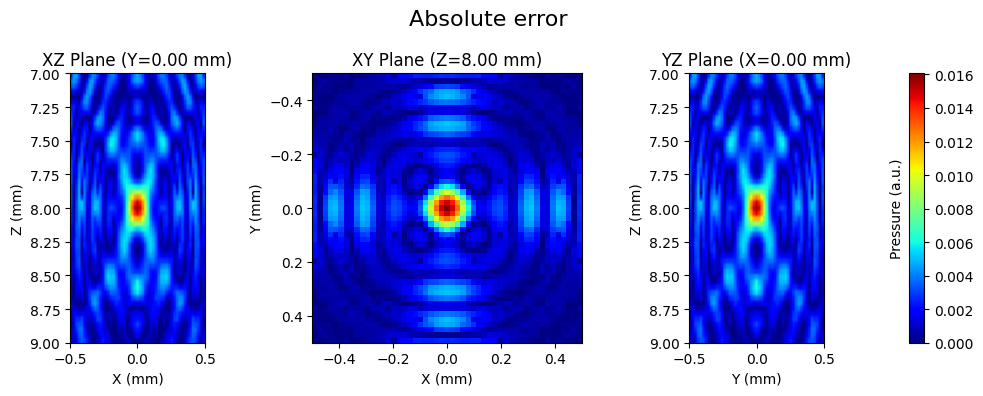

In [49]:
pyfield.plot_field_planes(x_m,y_m,z_m, pr_fieldii_matrix, vmin = 0, vmax = 1, figsize = (10,4), title="FIELD II")
pyfield.plot_field_planes(x_m,y_m,z_m, pr_pyfield_matrix, vmin = 0, vmax = 1, figsize = (10,4), title="PyField")
pyfield.plot_field_planes(x_m,y_m,z_m, np.abs(pr_pyfield_matrix-pr_fieldii_matrix), figsize = (10,4), title="Absolute error")

### 2.3.2. 3D Pressure field

In [38]:
def todB(A):
    return 20 * np.log10(np.abs(A+1e-80))

# General settings
scale = 1
title1 = "Pressure (dB)"
title2 = "Absolute \n Difference (dB)"
scalar_bar_args1 =  {
                "title": title1,
                "title_font_size": int(20 * scale),
                "label_font_size": int(18 * scale),
                "vertical": True,
                "position_x": 0.8,
                "position_y": 0.6,
                "height": 0.3,
            }

scalar_bar_args2=  {
                "title": title2,
                "title_font_size": int(20 * scale),
                "label_font_size": int(16 * scale),
                "vertical": True,
                "position_x": 0.8,
                "position_y": 0.6,
                "height": 0.3,
            }

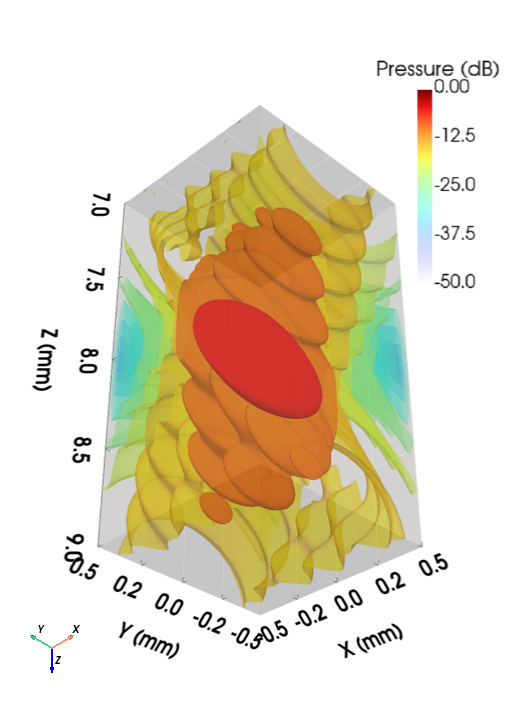

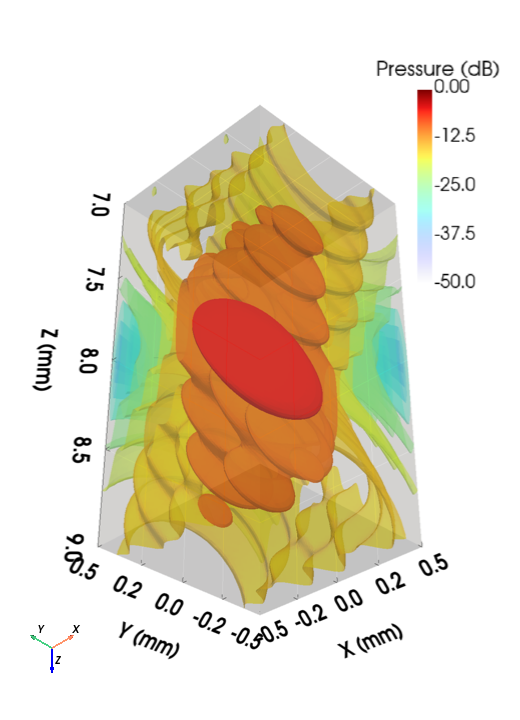

In [39]:
vmin = -50
vmax = 0
diff_linear_db = todB(pr_pyfield_linear - pr_fieldii_linear)

plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, todB(pr_fieldii_linear), notebook=True, vmin=vmin, vmax=vmax, scale = scale, scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')
plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, todB(pr_pyfield_linear), notebook=True, vmin=vmin, vmax=vmax, scale=scale, scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')


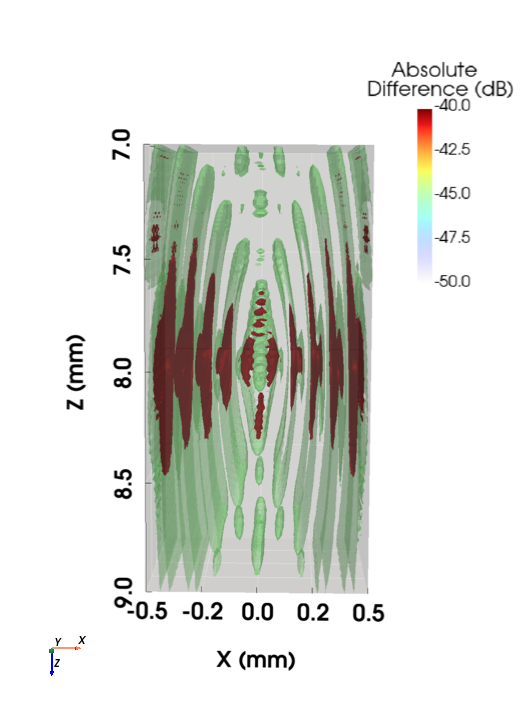

In [40]:

plotter = pyfield.plot_pressure_field(x_l,y_l,z_l, diff_linear_db, notebook=True, vmin=vmin, vmax=0, scale=scale, scalar_bar_args = scalar_bar_args2)
plotter.camera_position = [(0.12128995837459008, 6.401991884348098, 7.255906678402264),
 (0.0, 0.0, 8.0),
 (-0.006881270838449692, -0.11531983895076174, -0.9933045770839971)]
plotter.show(jupyter_backend='static')

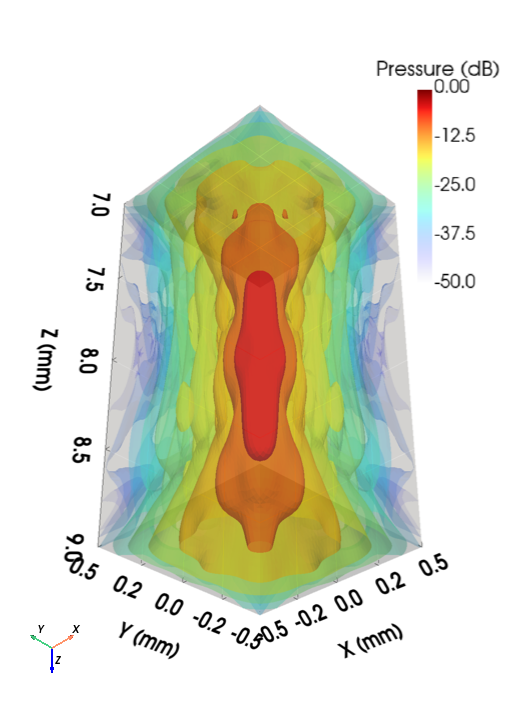

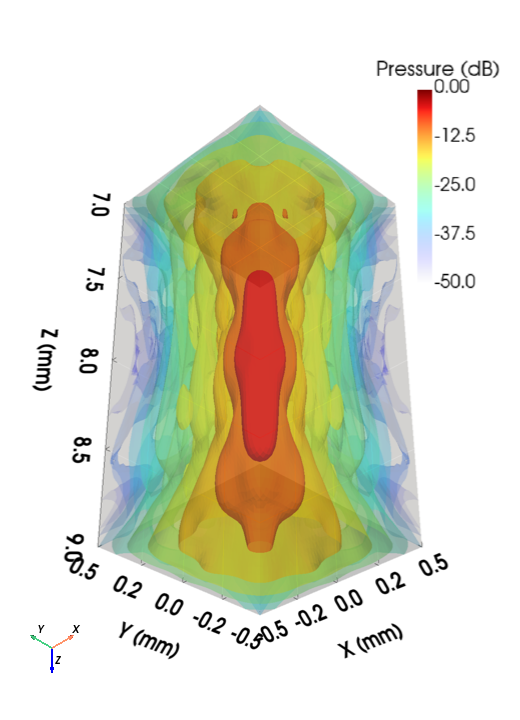

In [41]:
vmin = -50
diff__matrix_db = todB(pr_pyfield_matrix - pr_fieldii_matrix)

plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, todB(pr_fieldii_matrix), notebook=True, vmin=vmin, vmax=0, scale = scale, scalars = "Pressure (dB)", scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')
plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, todB(pr_pyfield_matrix), notebook=True, vmin=vmin, vmax=0, scale=scale, scalars = "Pressure (dB)", scalar_bar_args = scalar_bar_args1)
plotter.show(jupyter_backend='static')


 Difference (dB)' instead of 'Pressure'. Proceeding with 'Absolute 
 Difference (dB)'.


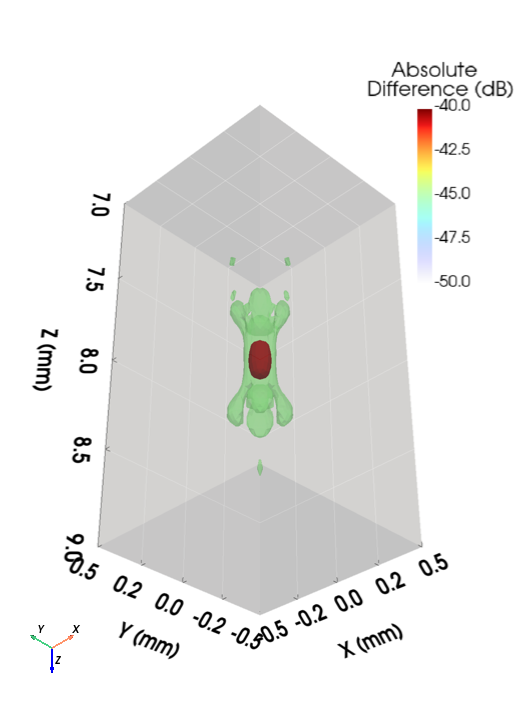

In [42]:
plotter = pyfield.plot_pressure_field(x_m,y_m,z_m, diff__matrix_db, notebook=True, vmin=vmin, vmax=0, scale=scale, scalars = "Absolute \n Difference (dB)", scalar_bar_args = scalar_bar_args2)
# plotter.camera_position = [(0.12128995837459008, 6.401991884348098, 7.255906678402264),
#  (0.0, 0.0, 8.0),
#  (-0.006881270838449692, -0.11531983895076174, -0.9933045770839971)]
plotter.show(jupyter_backend='static')